In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/gan-getting-started/monet_jpg/f4413e97bd.jpg
/kaggle/input/gan-getting-started/monet_jpg/7341d96c1d.jpg
/kaggle/input/gan-getting-started/monet_jpg/de6f71b00f.jpg
/kaggle/input/gan-getting-started/monet_jpg/99d94af5dd.jpg
/kaggle/input/gan-getting-started/monet_jpg/99a51d3e25.jpg
/kaggle/input/gan-getting-started/monet_jpg/d05cab011d.jpg
/kaggle/input/gan-getting-started/monet_jpg/4e05523825.jpg
/kaggle/input/gan-getting-started/monet_jpg/c68c52e8fc.jpg
/kaggle/input/gan-getting-started/monet_jpg/40d7d18ad3.jpg
/kaggle/input/gan-getting-started/monet_jpg/f96a8de9f3.jpg
/kaggle/input/gan-getting-started/monet_jpg/79224da51f.jpg
/kaggle/input/gan-getting-started/monet_jpg/23832dead5.jpg
/kaggle/input/gan-getting-started/monet_jpg/85580214be.jpg
/kaggle/input/gan-getting-started/monet_jpg/47a0548067.jpg
/kaggle/input/gan-getting-started/monet_jpg/fb93438ff9.jpg
/kaggle/input/gan-getting-started/monet_jpg/89d970411d.jpg
/kaggle/input/gan-getting-started/monet_jpg/7960adbd50.j

In [2]:
import os
import pandas as pd
import zipfile
import glob
from PIL import Image
%matplotlib inline
import matplotlib.pyplot as plt
import math
import numpy as np

In [3]:
monet_path=os.path.join(r"/kaggle/input/gan-getting-started","monet_jpg")
photo_path=os.path.join(r"/kaggle/input/gan-getting-started","photo_jpg")

In [4]:
# 数据集搭建
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader,Dataset
import random

class MonetDataset(Dataset):
    def __init__(self,monet_path,photo_path,size=(256,256)):
        super().__init__()
        random.seed(None)
        self.monet_path=glob.glob(monet_path+"/*")
        self.photo_path=glob.glob(photo_path+"/*")
        random.shuffle(self.monet_path)
        random.shuffle(self.photo_path)
        self.transforms=transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(size),
            transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
        ])
        random.seed(42)
    def __len__(self):
        return min(len(self.monet_path),len(self.photo_path))

    def __getitem__(self,idx):
        monet_img=self.transforms(Image.open(self.monet_path[idx]))
        photo_img=self.transforms(Image.open(self.photo_path[idx]))
        return monet_img,photo_img

In [5]:
def reverse_img(img,mean=[0.5]*3,std=[0.5]*3):
    for img_channel,mean_channel,std_channel in zip(img,mean,std):
        img_channel.mul_(std_channel).add_(mean_channel)
    return img

In [6]:
class Upsample_block(nn.Module):
    def __init__(self,in_ch,out_ch,dropout_ratio=0.5):
        super().__init__()
        self.upsample=nn.Upsample(scale_factor=2,mode="nearest")
        self.conv=nn.Conv2d(in_ch,out_ch,kernel_size=3,stride=1,padding=1)
        self.norm=nn.InstanceNorm2d(out_ch)
        self.dropout=nn.Dropout(dropout_ratio)
        self.activation=nn.GELU()
    def forward(self,X):
        return self.activation(self.dropout(self.norm(self.conv(self.upsample(X)))))

class Conv_block(nn.Module):
    def __init__(self,in_ch,out_ch,kernel_size=3,padding=1,stride=2):
        super().__init__()
        self.conv_layer=nn.Conv2d(in_ch,out_ch,kernel_size,stride=stride,padding=padding)
        self.activation=nn.GELU()
        self.norm=nn.InstanceNorm2d(out_ch)
    def forward(self,X):
        return self.activation(self.norm(self.conv_layer(X)))

class Res_Block(nn.Module):
    def __init__(self,ch):
        super().__init__()
        self.pad=nn.ReflectionPad2d(1)
        self.conv=nn.Conv2d(ch,ch,kernel_size=3,stride=1,padding=0)
        self.norm=nn.InstanceNorm2d(ch)
        self.activation=nn.GELU()
        self.dropout=nn.Dropout(0.4)
    def forward(self,X):
        X1=self.dropout(self.activation(self.norm(self.conv(self.pad(X)))))
        X2=self.dropout(self.activation(self.norm(self.conv(self.pad(X1)))))
        return X2+X

In [7]:
class Generator(nn.Module):
    def __init__(self,in_ch,out_ch,ResBlock_num=6):
        super().__init__()
        self.model=nn.Sequential(nn.ReflectionPad2d(3),
                           Conv_block(in_ch,64,7,stride=1,padding=0),
                           Conv_block(64,128,3,stride=2,padding=1),
                           Conv_block(128,256,3,stride=2,padding=1),
                            # 抽取特征
                            *[Res_Block(256) for _ in range(ResBlock_num)],
                            # 上采样
                            Upsample_block(256,128),
                            Upsample_block(128,64),
                            #抽取全局特征
                            nn.ReflectionPad2d(3),
                            nn.Conv2d(64,out_ch,7,stride=1,padding=0),
                            nn.Tanh()
                           )
    def forward(self,X):
        return self.model(X)
# PatchGAN

class Discriminator(nn.Module):
    def __init__(self,in_ch,num_layers=3):
        super().__init__()
        model=nn.Sequential(
            nn.Conv2d(in_ch,64,4,stride=2,padding=1),
            nn.GELU(),
        )
        for i in range(1,num_layers+1):
            in_ch=64*(2**(i-1))
            out_ch=in_ch*2
            if i ==num_layers:
                model.append(Conv_block(in_ch,out_ch,4,2))
            else :
                model.append(Conv_block(in_ch,out_ch,4,1))
        model.append(nn.Conv2d(2**(num_layers)*64,1,4,stride=1,padding=1))
        self.model=model
    def forward(self,X):
        return self.model(X)

In [8]:
def init_weight(m):
    class_name=m.__class__.__name__
    if class_name in ["Conv2d"]:
        nn.init.kaiming_normal_(m.weight,mode="fan_out",nonlinearity="relu")
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    if class_name=="Conv2d" and m.out_channels==3:
        nn.init.normal_(m.weight,std=0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [9]:
class sample_fake(object):
    def __init__(self, max_imgs=50):
        self.max_imgs = max_imgs
        self.imgs = []

    def __call__(self, imgs):
        # imgs: (batch, C, H, W)
        ret = []
        for img in imgs:
            if len(self.imgs) < self.max_imgs:
                self.imgs.append(img)
                ret.append(img)
            else:
                if np.random.rand() > 0.5:
                    idx = np.random.randint(0, self.max_imgs)
                    ret.append(self.imgs[idx])
                    self.imgs[idx] = img
                else:
                    ret.append(img)
        # 返回 batch tensor，保证 shape 一致
        return torch.stack(ret)

In [10]:
class lr_sched():
    def __init__(self, decay_epochs=100, total_epochs=200):
        self.decay_epochs = decay_epochs
        self.total_epochs = total_epochs

    def step(self, epoch_num):
        if epoch_num <= self.decay_epochs:
            return 1.0
        else:
            fract = (epoch_num - self.decay_epochs)  / (self.total_epochs - self.decay_epochs)
            return 1.0 - fract

In [11]:
class Accumulator:
    def __init__(self,num):
        self.metric=[0]*num
    def __getitem__(self,idx):
        return self.metric[idx]
    def add(self,*args):
        if args:
            for i,arg in enumerate(args):
                self.metric[i]+=arg

class Recorder:
    def __init__(self,num):
        self.metric=[[] for _ in range(num)]
    def __getitem__(self,idx):
        return self.metric[idx]
    def __len__(self):
        return len(self.metric)
    def add(self,*args):
        if args:
            for i,arg in enumerate(args):
                self.metric[i].append(arg)

In [12]:
def Frozen(nets,training=True):
    for net in nets:
        for param in net.parameters():
                param.requires_grad=training

In [13]:
# 采用混合精度训练
from torch import amp
torch.backends.cudnn.benchmark=True
torch.backends.cuda.matmul.allow_tf32=True
torch.backends.cudnn.allow_tf32=True

In [14]:
import time

def show_img(transformed_imgs, true_imgs):
    plt.figure(figsize=(8, 4))

    plt.subplot(121)
    plt.imshow(transformed_imgs[-1])
    plt.axis("off")
    plt.title("Generated")

    plt.subplot(122)
    plt.imshow(true_imgs[-1])
    plt.axis("off")
    plt.title("True")

    plt.tight_layout()
    plt.show()

    time.sleep(2)
    plt.close()

In [15]:
def show_chart(net):
    series=np.arange(len(net.record_metric[0]))
    plt.plot(series,net.record_metric[0],"r-",label="G_loss")
    plt.plot(series,net.record_metric[1],"b-",label="D_loss")
    plt.legend()
    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.title("loss curve")
    plt.savefig(".\Storage\loss_curve.png")
    plt.show()

In [16]:
import os
import torch

def save_generator_only(net, save_dir="./Storage"):
    os.makedirs(save_dir, exist_ok=True)                    
    torch.save(net.G_Monet2Photo.state_dict(), 
               os.path.join(save_dir, "G_Monet2Photo.pth"))
    
    torch.save(net.G_Photo2Monet.state_dict(), 
               os.path.join(save_dir, "G_Photo2Monet.pth"))
    
    print(f"生成器已成功保存到 {save_dir}/ 目录")
    print("  ├─ G_Monet2Photo.pth")
    print("  └─ G_Photo2Monet.pth")


In [17]:
# 设置种子
configue={
    "batch_size":8,
    "seed":42,
    "epochs":200,
    "device":"cuda" if torch.cuda.is_available() else "cpu",
    "start_lr":2e-4,
    "temp":10,
    "idt_coef":0.5,
    "decay_epoch":0
}

In [21]:
# 转换接口
os.makedirs(".\Image",exist_ok=True)

class PhotoDataset(Dataset):
    def __init__(self,photo_path,size=(256,256),configue=configue):
        super().__init__()
        random.seed(None)
        self.photo_path=glob.glob(photo_path+"/*")
        random.shuffle(self.photo_path)
        self.transforms=transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(size),
            transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
        ])
        random.seed(configue["seed"])
    def __len__(self):
        return len(self.photo_path)

    def __getitem__(self,idx):
        photo_img=self.transforms(Image.open(self.photo_path[idx]))
        return photo_img

photo_iter=DataLoader(PhotoDataset(photo_path),batch_size=1,shuffle=True,pin_memory=True)

@torch.no_grad
def Transformer_image(net, data_iter, configue=configue, num=1):
    net.G_Monet2Photo.eval()
    net.G_Photo2Monet.eval()
    net.D_Monet.eval()
    net.D_Photo.eval()
    true_imgs, transformed_imgs = [], []
    for i, img in enumerate(data_iter):
        if i == num:
            break
        device = configue["device"]
        img = img.to(device)
        transformed_img = net.G_Photo2Monet(img)
        transformed_img = reverse_img(transformed_img.cpu()[0])
        transformed_img = transforms.ToPILImage()(transformed_img).convert("RGB")
        transformed_imgs.append(transformed_img)

        img = reverse_img(img.cpu())
        img = transforms.ToPILImage()(img[0]).convert("RGB")
        true_imgs.append(img)

        transformed_img.save(f".\Image\{i}.jpg")
    return transformed_imgs, true_imgs

In [24]:
class CycleGAN:
    def __init__(self,in_ch,out_ch,configue):
        self.configue=configue
        self.epochs=configue["epochs"]
        self.start_lr=configue["start_lr"]
        self.temp=configue["temp"]
        self.decay_epoch=configue["decay_epoch"] if configue["decay_epoch"] else int(self.epochs/2)
        self.idt_coef=configue["idt_coef"]
        self.device=configue["device"]
        self.G_Monet2Photo=Generator(in_ch,out_ch)
        self.G_Photo2Monet=Generator(in_ch,out_ch)
        self.D_Monet=Discriminator(in_ch)
        self.D_Photo=Discriminator(in_ch)

        self.mseloss=nn.MSELoss()
        self.l1loss=nn.L1Loss()
        self.G_adam=torch.optim.AdamW(itertools.chain(self.G_Monet2Photo.parameters(),self.G_Photo2Monet.parameters()),
                                     lr=self.start_lr,betas=(0.5,0.999))
        self.D_adam=torch.optim.AdamW(itertools.chain(self.D_Monet.parameters(),self.D_Photo.parameters()),
                                     lr=self.start_lr,betas=(0.5,0.999))

        self.sample_monet=sample_fake()
        self.sample_photo=sample_fake()

        G_lr=lr_sched(self.decay_epoch,self.epochs)
        D_lr=lr_sched(self.decay_epoch,self.epochs)
        self.G_sched=torch.optim.lr_scheduler.LambdaLR(self.G_adam,G_lr.step)
        self.D_sched=torch.optim.lr_scheduler.LambdaLR(self.D_adam,D_lr.step)
        self.record_metric=Recorder(2)

        self.init()
    def init(self):
        self.G_Monet2Photo.apply(init_weight)
        self.G_Photo2Monet.apply(init_weight)
        self.D_Monet.apply(init_weight)
        self.D_Photo.apply(init_weight)

        self.G_Monet2Photo=self.G_Monet2Photo.to(self.device)
        self.G_Photo2Monet=self.G_Photo2Monet.to(self.device)
        self.D_Monet=self.D_Monet.to(self.device)
        self.D_Photo=self.D_Photo.to(self.device)


    def train(self,data_iter):
        epochs=self.configue["epochs"]
        device=self.configue["device"]
        
        record_metric=self.record_metric
        scaler=amp.GradScaler("cuda")
        for epoch in range(epochs):
            add_metric=Accumulator(3)
            pbar=tqdm.tqdm(data_iter,total=len(data_iter),leave=False,desc=f"{epoch+1}/{epochs}")
            for i,(monet_img,photo_img) in enumerate(pbar):
                # ============================生成器============================
                Frozen([self.D_Monet,self.D_Photo],False)
                monet_img,photo_img=monet_img.to(device,non_blocking=True),photo_img.to(device,non_blocking=True)
                self.G_adam.zero_grad()
                #混合精度的前向传播
                with amp.autocast("cuda",enabled=True):
                    fake_photo=self.G_Monet2Photo(monet_img)
                    fake_monet=self.G_Photo2Monet(photo_img)
                    cycle_monet=self.G_Photo2Monet(fake_monet)
                    cycle_photo=self.G_Monet2Photo(fake_monet)
                    id_monet=self.G_Photo2Monet(monet_img)
                    id_photo=self.G_Monet2Photo(photo_img)
    
                    #身份损失---不能改变本来就是目标身份的图片
                    id_monet_loss=self.l1loss(id_monet,monet_img)*self.temp*self.idt_coef
                    id_photo_loss=self.l1loss(id_photo,photo_img)*self.temp*self.idt_coef
                    # 循环损失---确保内容主体不改变，否则生成器只会骗判别器而全然不管内容主体，因此大权重
                    cycle_monet_loss=self.l1loss(cycle_monet,monet_img)*self.temp
                    cycle_photo_loss=self.l1loss(cycle_photo,photo_img)*self.temp
                    # 对抗损失---判别器能否正确判断真假，这是我们严格要求的，所以加上 mseloss，即不允许容忍极端值
                    monet_disc=self.D_Monet(fake_monet)
                    photo_disc=self.D_Photo(fake_photo)
                    # real=torch.ones(monet_disc.size()).to(device)
                    real=torch.ones_like(monet_disc).to(device)
                    monet_adv_loss=self.mseloss(monet_disc,real)
                    photo_adv_loss=self.mseloss(photo_disc,real)
                    # 总损失
                    G_total_loss=id_monet_loss+id_photo_loss+cycle_monet_loss+\
                                    cycle_photo_loss+monet_adv_loss+photo_adv_loss
                scaler.scale(G_total_loss).backward()
                #因为上述损失与生成器目标一致，所以我们希望优化器同时兼顾这些损失
                scaler.unscale_(self.G_adam)
                scaler.step(self.G_adam)
                scaler.update()
                
               # ============================判别器============================
                Frozen([self.D_Monet,self.D_Photo],True)
                self.D_adam.zero_grad()

                with amp.autocast("cuda",enabled=True):
                    fake_monet = self.sample_monet(fake_monet.cpu().detach()).to(device)
                    fake_photo = self.sample_photo(fake_photo.cpu().detach()).to(device)
                    
                    monet_real_disc=self.D_Monet(monet_img)
                    monet_fake_disc=self.D_Monet(fake_monet)
                    photo_real_disc=self.D_Photo(photo_img)
                    photo_fake_disc=self.D_Photo(fake_photo)
    
                    # 通用的判别值
                    # real_dsic=torch.ones(monet_real_disc.size(),device=device)
                    # fake_disc=torch.zeros(monet_fake_disc.size(),device=device)
                    real_dsic=torch.ones_like(monet_real_disc,device=device)
                    fake_disc=torch.zeros_like(monet_fake_disc,device=device)
                    # 真的判别为真，假的判别为假
                    monet_real_loss=self.mseloss(monet_real_disc,real_dsic)
                    monet_fake_loss=self.mseloss(monet_fake_disc,fake_disc)
                    photo_real_loss=self.mseloss(photo_real_disc,real_dsic)
                    photo_fake_loss=self.mseloss(photo_fake_disc,fake_disc)
                    #总损失
                    monet_disc_loss=(monet_real_loss+monet_fake_loss)/2
                    photo_disc_loss=(photo_real_loss+photo_fake_loss)/2
                    D_total_loss=monet_disc_loss+photo_disc_loss
                scaler.scale(D_total_loss).backward()
                scaler.unscale_(self.D_adam)
                scaler.step(self.D_adam)
                scaler.update()
                
                add_metric.add(G_total_loss.item(),D_total_loss.item(),len(monet_img))
                #进度条更新
                pbar.set_postfix(G_loss=G_total_loss.item(),D_loss=D_total_loss.item())
            record_metric.add(add_metric[0]/add_metric[-1],add_metric[1]/add_metric[-1])
            print(f"<{epoch+1}/{epochs}>---<G_loss {add_metric[0]/add_metric[-1]}>---<M_loss  {add_metric[1]/add_metric[-1]}>")
            self.G_sched.step()
            self.D_sched.step()
            if (epoch+1)%20==0:
                transformed_imgs, true_imgs=Transformer_image(net,photo_iter)
                show_img(transformed_imgs, true_imgs)
                save_generator_only(net)

<1/200>---<G_loss 69.0977919514974>---<M_loss  77.7094014485677>


<2/200>---<G_loss 9.688213717142741>---<M_loss  8.084763151804607>


<3/200>---<G_loss 3.978224557240804>---<M_loss  2.061027755737305>


<4/200>---<G_loss 3.166578114827474>---<M_loss  1.0533098300298056>


<5/200>---<G_loss 2.8652442487080894>---<M_loss  0.7250760984420777>


...

<14/200>---<G_loss 2.0133211326599123>---<M_loss  0.1794032210111618>


<15/200>---<G_loss 1.9971762784322102>---<M_loss  0.20168589194615683>


<16/200>---<G_loss 1.9345128949483235>---<M_loss  0.1618598477045695>


<17/200>---<G_loss 1.9700843207041423>---<M_loss  0.2668368679285049>


<20/200>---<G_loss 1.8795053704579672>---<M_loss  0.17262868225574493>


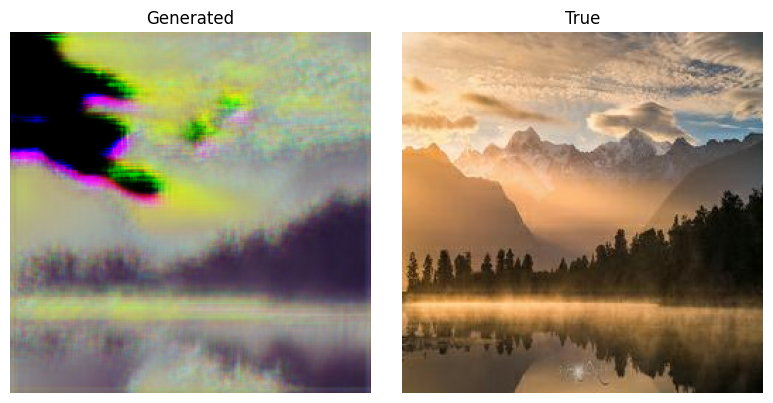

生成器已成功保存到 ./Storage/ 目录
  ├─ G_Monet2Photo.pth
  └─ G_Photo2Monet.pth


<21/200>---<G_loss 1.994397408167521>---<M_loss  0.42986542840798697>


<22/200>---<G_loss 1.6184298261006673>---<M_loss  0.10357461512088775>


<23/200>---<G_loss 1.5892749309539795>---<M_loss  0.10884839137395223>


24/200:  26%|██▋       | 10/38 [00:15<00:42,  1.52s/it, D_loss=1.13, G_loss=11.7]

In [ ]:
import itertools
import tqdm

def seed_(seed):
    random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)
    np.random.seed(42)
        
seed_(configue["seed"])
os.makedirs(".\Storage",exist_ok=True)
os.makedirs(".\Image",exist_ok=True)

data_iter=DataLoader(MonetDataset(monet_path,photo_path),
                     batch_size=configue["batch_size"],
                     shuffle=True,
                     pin_memory=True,)
net=CycleGAN(3,3,configue)
net.train(data_iter)

In [ ]:
show_chart(net)
save_generator_only(net)

In [ ]:
transformed_imgs, true_imgs=Transformer_image(net,photo_iter)
show_img(transformed_imgs, true_imgs)

In [ ]:
import zipfile



# 测试集路径（Kaggle Notebook 里就是这个）
test_paths = sorted(glob.glob("/kaggle/input/gan-getting-started/photo_jpg/*.jpg"))

with torch.no_grad():
    with zipfile.ZipFile("images.zip", "w") as zf:
        for i, path in enumerate(test_paths):
            img = Image.open(path).convert("RGB")
            img = transforms.ToTensor()(img).unsqueeze(0).to(device)
            img = transforms.Normalize([0.5]*3, [0.5]*3)(img)
            
            fake = G(img)
            fake = reverse_img(fake.squeeze(0).cpu())  # 您的反归一化函数
            fake = transforms.ToPILImage()(fake).convert("RGB")
            fake.save("temp.jpg")
            zf.write("temp.jpg", arcname=f"{i+1}.jpg")

print("images.zip 生成完毕，直接提交即可！")